# Is the `n×0` − `0×n` effect real at the student level?

`n×0` is answered ~40 ms slower than `0×n` (`rt_zero_direction.ipynb`). That estimate pools trials, so it
could in principle be produced by a few high-frequency students, by differences in multiplication
proficiency, or by generally slow students showing larger millisecond differences. This notebook attacks
the estimate from six directions that make different assumptions, plus accuracy as a second outcome.

**A design constraint that shapes everything below.** A998 is a fluency test, not a psychophysics
experiment: the median student contributes **2 correct trials per condition** (75th percentile 3, max 15).
A per-student effect is therefore estimated with very little information, and no analysis here can
recover a reliable individual-level effect. What the data can establish is whether the effect is a
*population-level within-student* shift that does not depend on who the student is — which is what the
random-slope variance, the student-level delta distribution and the equal-weight resampling test.

Queries: `queries/rt_zero_facts_trials.sql` (one row per kept response to a 0-fact, correct and incorrect)
and `queries/student_controls.sql` (proficiency and speed measured outside the zero problems).
Filters as `DECISIONS.txt` #1–#11, #18. ES_2025, `0×0` excluded (#15).

In [3]:
import logging, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from pyfixest.estimation import feglm, feols
from scipy.stats import ttest_1samp, wilcoxon

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
from plot_style import C_DIR, C_OTHER, C_ZERO, FONT_BIG, FONT_MED, paint_it_black, set_style

PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
YEAR, SEED = "ES_2025", 20260921
MIN_N = 30                      # DECISIONS #11, per fact x age cell
N_BOOT, N_SUBSAMPLE, MIXED_STUDENTS = 2000, 200, 20_000
rng = np.random.default_rng(SEED)
logging.getLogger('fontTools').setLevel(logging.WARNING)   # PDF export logs every glyph otherwise
set_style()
fmt = lambda p: "< .001" if p < .001 else f"= {p:.3f}"

In [4]:
import re
def _year(path, year):
    return re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", path.read_text(encoding="utf-8"))

def load(year):
    '''Trial-level 0-fact responses joined to the student controls. Returns (all trials, correct only).'''
    cells = cached_query(ROOT / "queries/rt_error_by_fact_age.sql", cache_dir=ROOT / "cache",
                         sql_text=_year(ROOT / "queries/rt_error_by_fact_age.sql", year))
    t = cached_query(ROOT / "queries/rt_zero_facts_trials.sql", cache_dir=ROOT / "cache",
                     sql_text=_year(ROOT / "queries/rt_zero_facts_trials.sql", year))
    t = t[pd.MultiIndex.from_arrays([t.course_age, t.operation]).isin(set(zip(cells.course_age, cells.operation)))]
    t = t[~(t.left_factor.eq(0) & t.right_factor.eq(0))].copy()          # 0×0 belongs to neither order (#15)
    t["nx0"] = t.right_factor.eq(0).astype(float)                        # 1 = large-first (n×0), 0 = 0×n
    t["n"] = np.where(t.left_factor.eq(0), t.right_factor, t.left_factor)
    t["correct"] = t.statement_result.eq("Correct").astype(float)

    ctl = cached_query(ROOT / "queries/student_controls.sql", cache_dir=ROOT / "cache",
                       sql_text=_year(ROOT / "queries/student_controls.sql", year))
    ctl = ctl.rename(columns={"acc_base": "level", "mean_lnrt_base": "speed"})
    d = t.merge(ctl[["student_uuid", "level", "speed", "n_base"]], on="student_uuid", how="inner")
    d["age_c"] = d.course_age - d.course_age.mean()
    for col in ("level", "speed"):                                       # standardised WITHIN age
        g = d.groupby("course_age")[col]
        d[col + "_z"] = (d[col] - g.transform("mean")) / g.transform("std")
    d = d.dropna(subset=["level_z", "speed_z"])
    c = d[d.statement_result.eq("Correct")].copy()
    c["log_rt"] = np.log(c.rt_seconds)
    return t, d, c

trials_all, d, c = load(YEAR)
cov = (c.groupby("course_age").agg(trials=("rt_seconds", "size"), students=("student_uuid", "nunique"),
                                   median_rt_0xn=("rt_seconds", "median"))
        .join(d.groupby("course_age").size().rename("trials_incl_errors")))
cov["trials_per_student"] = (cov.trials / cov.students).round(2)
print(f"0-fact trials kept: {len(trials_all):,} | with controls: {len(d):,} | correct: {len(c):,}")
print(f"students: {trials_all.student_uuid.nunique():,} -> {c.student_uuid.nunique():,} with controls "
      f"(controls need >= 20 non-zero trials)")
display(cov)

0-fact trials kept: 501,851 | with controls: 347,411 | correct: 316,277
students: 112,409 -> 59,175 with controls (controls need >= 20 non-zero trials)


,trials,students,median_rt_0xn,trials_incl_errors,trials_per_student
course_age,,,,,
9,23131,12191,2.647,28536,1.90
10,64229,12024,2.235,71541,5.34
11,87268,14999,2.081,96028,5.82
12,49560,7471,2.000,53709,6.63
13,55696,7708,1.865,59635,7.23
14,29235,3814,1.800,30617,7.67
15,7158,968,1.766,7345,7.39


## The two student-level controls

Both are estimated **outside the zero problems**, so they cannot absorb the effect being tested:

- `student_level` — accuracy over every kept response to a fact with no zero operand.
- `student_speed` — mean log RT over the *correct* ones. Higher = **slower**, not faster.

Both are standardised within age, so they carry no age information. `student_level` and `student_speed`
are absorbed by the student fixed effect in the within-student models; what those models identify is
their *interaction* with order, which is the question that matters — does the size of the order effect
depend on who the student is.

In [5]:
print(c[["level", "speed"]].describe().round(3).to_string())
print(f"\ncorrelation level ~ speed (within-age z): {c.level_z.corr(c.speed_z):+.3f}")
print(f"median non-zero trials behind a student's controls: {c.groupby('student_uuid').n_base.max().median():.0f}")

            level       speed
count  316277.000  316277.000
mean        0.900       1.236
std         0.111       0.242
min         0.016      -0.235
25%         0.871       1.068
50%         0.930       1.224
75%         0.967       1.391
max         1.000       2.825

correlation level ~ speed (within-age z): -0.175
median non-zero trials behind a student's controls: 30


## 1. Trial-level models

Trials are not independent — they are nested in students and in facts. Two estimators, with different
assumptions and the same target:

- **Fixed effects** (`pyfixest`): student and fact absorbed, standard errors clustered by student. Makes no
  distributional assumption about the student effects; the order coefficient is identified purely within
  student.
- **Mixed model** (`statsmodels`): random intercept **and random slope of order by student**, fact as a
  fixed effect (only 9 levels: the non-zero operand). The random-slope variance is the direct test of
  whether the effect differs between students. Fitted on a random subsample of 20,000 students — the full
  sample does not fit in memory — so its standard errors are wider than the fixed-effects model's by
  construction.

Outcome is `log(RT)` throughout — RT is strongly right-skewed and a log effect is a proportional one, which
is also the answer to "do slower students just show bigger millisecond differences". Effects are converted
back to milliseconds at the observed `0×n` median.

In [6]:
def to_ms(beta, base):
    return 1000 * base * (np.exp(beta) - 1)

BASE = c.loc[c.nx0.eq(0), "rt_seconds"].median()
print(f"baseline: median RT of 0×n = {BASE:.3f} s")

fe = {}
fe["within student + fact"] = feols("log_rt ~ nx0 | student_uuid + n", data=c, vcov={"CRV1": "student_uuid"})
fe["+ order × age, level, speed"] = feols(
    "log_rt ~ nx0 + nx0:age_c + nx0:level_z + nx0:speed_z | student_uuid + n", data=c, vcov={"CRV1": "student_uuid"})
fe["fact FE only (main effects)"] = feols(
    "log_rt ~ nx0*age_c + level_z + speed_z + nx0:level_z + nx0:speed_z | n", data=c, vcov={"CRV1": "student_uuid"})
# the control merge drops students with < 20 non-zero trials -- check it is not doing the work
c_all = trials_all[trials_all.statement_result.eq("Correct")].assign(log_rt=lambda x: np.log(x.rt_seconds))
fe["all students, no controls"] = feols("log_rt ~ nx0 | student_uuid + n", data=c_all, vcov={"CRV1": "student_uuid"})

for name, m in fe.items():
    print(f"\n[{name}]  n = {m._N:,}")
    print(m.tidy().round(5).to_string())

baseline: median RT of 0×n = 2.033 s


c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 7485 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 7485 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 19739 singleton fixed effect(s) dropped from the model.
  warnings.warn(



[within student + fact]  n = 308,792
             Estimate  Std. Error   t value  Pr(>|t|)     2.5%   97.5%
Coefficient                                                           
nx0           0.01996      0.0017  11.72258       0.0  0.01663  0.0233

[+ order × age, level, speed]  n = 308,792
             Estimate  Std. Error   t value  Pr(>|t|)     2.5%    97.5%
Coefficient                                                            
nx0           0.01944     0.00177  10.98982   0.00000  0.01598  0.02291
nx0:age_c     0.00148     0.00115   1.28471   0.19890 -0.00078  0.00373
nx0:level_z   0.00254     0.00222   1.14514   0.25216 -0.00181  0.00689
nx0:speed_z  -0.00141     0.00183  -0.77148   0.44043 -0.00499  0.00217

[fact FE only (main effects)]  n = 316,277
             Estimate  Std. Error   t value  Pr(>|t|)     2.5%    97.5%
Coefficient                                                            
nx0           0.01781     0.00166  10.70306   0.00000  0.01455  0.02107
age_c        

In [7]:
b = fe["+ order × age, level, speed"].tidy().loc["nx0"]
print(f"order effect: {b['Estimate']:+.4f} log units = {100 * (np.exp(b['Estimate']) - 1):+.2f}% "
      f"= {to_ms(b['Estimate'], BASE):+.1f} ms [{to_ms(b['2.5%'], BASE):+.1f}, {to_ms(b['97.5%'], BASE):+.1f}], "
      f"t = {b['t value']:.1f}, p {fmt(b['Pr(>|t|)'])}")

order effect: +0.0194 log units = +1.96% = +39.9 ms [+32.7, +47.1], t = 11.0, p < .001


In [8]:
# a random-slope model over all 59k students exhausts the machine, so it is fitted on a random
# subsample of students; the fixed-effects model above already uses every trial
mx_ids = rng.choice(c.student_uuid.unique(), size=min(MIXED_STUDENTS, c.student_uuid.nunique()), replace=False)
mx_data = c[c.student_uuid.isin(mx_ids)]
t0 = time.time()
mx = smf.mixedlm("log_rt ~ nx0*age_c + level_z + speed_z + nx0:level_z + nx0:speed_z + C(n)",
                 mx_data, groups=mx_data.student_uuid, re_formula="~nx0").fit(method="lbfgs", maxiter=300)
print(f"MixedLM: {mx_data.student_uuid.nunique():,} students (random subsample), {len(mx_data):,} trials, "
      f"{time.time() - t0:.0f}s, converged = {mx.converged}")
tab = mx.summary().tables[1]
print(tab.loc[[i for i in tab.index if "nx0" in i or "Var" in i or "Cov" in i]].to_string())
print(f"\nrandom slope SD of order = {np.sqrt(max(mx.cov_re.iloc[-1, -1], 0)):.4f} log units, against a "
      f"fixed effect of {mx.params['nx0']:.4f}")

C:\Users\maria.garcia\AppData\Local\Temp\ipykernel_3824\1976908059.py:7: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  mx_data, groups=mx_data.student_uuid, re_formula="~nx0").fit(method="lbfgs", maxiter=300)


MixedLM: 20,000 students (random subsample), 107,214 trials, 56s, converged = True
                  Coef. Std.Err.       z  P>|z|  [0.025 0.975]
nx0               0.016    0.003   5.566  0.000   0.010  0.021
nx0:age_c         0.001    0.002   0.305  0.760  -0.003  0.004
nx0:level_z       0.007    0.003   2.354  0.019   0.001  0.014
nx0:speed_z      -0.000    0.003  -0.090  0.928  -0.006  0.005
Group Var         0.017    0.002                              
Group x nx0 Cov  -0.001    0.002                              
nx0 Var           0.000    0.004                              

random slope SD of order = 0.0073 log units, against a fixed effect of 0.0157


## 2. Does the effect depend on proficiency or on general speed?

The three interaction terms above answer this directly. Read them together with the main effect.

In [9]:
q = fe["+ order × age, level, speed"].tidy()
for term, question in [("nx0", "order effect at the average student"),
                       ("nx0:age_c", "does it change with age"),
                       ("nx0:level_z", "does it depend on multiplication proficiency"),
                       ("nx0:speed_z", "does it depend on general slowness")]:
    r = q.loc[term]
    print(f"{question:45s} {r['Estimate']:+.4f} [{r['2.5%']:+.4f}, {r['97.5%']:+.4f}]  p {fmt(r['Pr(>|t|)'])}")

order effect at the average student           +0.0194 [+0.0160, +0.0229]  p < .001
does it change with age                       +0.0015 [-0.0008, +0.0037]  p = 0.199
does it depend on multiplication proficiency  +0.0025 [-0.0018, +0.0069]  p = 0.252
does it depend on general slowness            -0.0014 [-0.0050, +0.0022]  p = 0.440


## 3. One student, one effect

Each student contributes a single number: the difference of their median RTs. The mean is reported for
completeness but the median is the estimate to read — a per-student delta built on ~2 trials per condition
has enormous tails (the same heavy-tail problem as `DECISIONS #19`).

In [10]:
w = (c.groupby(["student_uuid", "nx0"]).agg(rt=("rt_seconds", "median"), lrt=("log_rt", "median"),
                                            k=("rt_seconds", "size")).unstack("nx0").dropna())
w.columns = [f"{a}_{int(b)}" for a, b in w.columns]
w["delta"] = 1000 * (w.rt_1 - w.rt_0)                       # ms
w["dlog"] = w.lrt_1 - w.lrt_0                               # log units
w["prop"] = (w.rt_1 - w.rt_0) / w.rt_0                      # proportional
w = w.join(c.groupby("student_uuid").agg(age=("course_age", "max"), level_z=("level_z", "max"),
                                         speed_z=("speed_z", "max")))

def one_sample(x, label, unit=""):
    t = ttest_1samp(x, 0); ci = t.confidence_interval()
    ww = wilcoxon(x[x != 0])
    boot = np.array([np.median(rng.choice(x.values, len(x), replace=True)) for _ in range(N_BOOT)])
    print(f"{label}: n = {len(x):,} | mean {x.mean():+.3f}{unit} [{ci.low:+.3f}, {ci.high:+.3f}], "
          f"t = {t.statistic:.2f}, p {fmt(t.pvalue)}")
    print(f"{'':{len(label)}}  median {x.median():+.3f}{unit} boot 95% CI "
          f"[{np.percentile(boot, 2.5):+.3f}, {np.percentile(boot, 97.5):+.3f}] | "
          f"Wilcoxon p {fmt(ww.pvalue)} | {100 * (x > 0).mean():.1f}% of students > 0")
    return {"n": len(x), "mean": x.mean(), "median": x.median(),
            "lo": np.percentile(boot, 2.5), "hi": np.percentile(boot, 97.5), "pct_pos": 100 * (x > 0).mean()}

delta_stats = one_sample(w.delta, "delta RT", " ms")
_ = one_sample(w.dlog, "delta log", "")
print(f"proportional: median {100 * w.prop.median():+.2f}% (the mean is {100 * w.prop.mean():+.1f}%, "
      f"which the tails own)")

delta RT: n = 45,615 | mean +44.495 ms [+21.201, +67.790], t = 3.74, p < .001
          median +34.000 ms boot 95% CI [+33.000, +42.000] | Wilcoxon p < .001 | 53.4% of students > 0
delta log: n = 45,615 | mean +0.018 [+0.014, +0.022], t = 8.85, p < .001
           median +0.019 boot 95% CI [+0.017, +0.021] | Wilcoxon p < .001 | 53.5% of students > 0
proportional: median +1.90% (the mean is +14.9%, which the tails own)


In [11]:
by_age_student = {}
for age, g in w.groupby("age"):
    t = ttest_1samp(g.delta, 0); ci = t.confidence_interval()
    ww = wilcoxon(g.delta[g.delta != 0])
    by_age_student[age] = {"students": len(g), "mean_ms": g.delta.mean(), "t_lo": ci.low, "t_hi": ci.high,
                           "p_t": t.pvalue, "median_ms": g.delta.median(), "p_wilcoxon": ww.pvalue,
                           "pct_pos": 100 * (g.delta > 0).mean()}
by_age_student = pd.DataFrame(by_age_student).T.rename_axis("course_age")
display(by_age_student.round({"mean_ms": 1, "t_lo": 1, "t_hi": 1, "p_t": 4, "median_ms": 1,
                              "p_wilcoxon": 6, "pct_pos": 1}))

,students,mean_ms,t_lo,t_hi,p_t,median_ms,p_wilcoxon,pct_pos
course_age,,,,,,,,
9,4382.0,48.8,-79.9,177.4,0.4574,65.5,0.002093,52.8
10,10066.0,43.1,-5.5,91.7,0.0821,33.0,0.000234,52.0
11,12975.0,37.6,-3.5,78.7,0.0733,33.5,0.000000,53.0
12,6704.0,57.5,5.2,109.7,0.0311,37.0,0.000000,53.7
13,7048.0,33.1,-16.3,82.4,0.1888,42.8,0.000000,55.2
14,3537.0,64.9,8.9,120.9,0.0231,33.0,0.000000,54.8
15,903.0,51.6,-28.9,132.0,0.2087,41.0,0.000100,56.9


In [12]:
print("delta_ms ~ age + level + speed")
print(smf.ols("delta ~ age + level_z + speed_z", w).fit().summary2().tables[1].round(3).to_string())
print("\ndelta_log ~ age + level + speed   (the scale-free version of the same regression)")
print(smf.ols("dlog ~ age + level_z + speed_z", w).fit().summary2().tables[1].round(4).to_string())
print("\nwith the interactions the sample supports:")
print(smf.ols("dlog ~ age * level_z + age * speed_z", w).fit().summary2().tables[1].round(4).to_string())

delta_ms ~ age + level + speed
            Coef.  Std.Err.      t  P>|t|   [0.025   0.975]
Intercept  26.373    90.785  0.290  0.771 -151.568  204.313
age         1.517     7.929  0.191  0.848  -14.023   17.058
level_z     9.379    12.815  0.732  0.464  -15.739   34.497
speed_z     6.578    12.326  0.534  0.594  -17.582   30.737

delta_log ~ age + level + speed   (the scale-free version of the same regression)
            Coef.  Std.Err.       t   P>|t|  [0.025  0.975]
Intercept -0.0055    0.0154 -0.3601  0.7188 -0.0357  0.0246
age        0.0021    0.0013  1.5407  0.1234 -0.0006  0.0047
level_z    0.0027    0.0022  1.2286  0.2192 -0.0016  0.0069
speed_z   -0.0022    0.0021 -1.0534  0.2922 -0.0063  0.0019

with the interactions the sample supports:
              Coef.  Std.Err.       t   P>|t|  [0.025  0.975]
Intercept   -0.0069    0.0154 -0.4462  0.6555 -0.0372  0.0234
age          0.0022    0.0013  1.6107  0.1073 -0.0005  0.0048
level_z      0.0272    0.0166  1.6363  0.1018 -0.0054  0

## 4. Matched within student **and** within the non-zero operand

The strongest descriptive contrast: the same student answering the same fact in both orders (`7×0` against
`0×7`), so student, fact, proficiency and general speed are all held constant by construction. Cells are
averaged within student before the test, so a student with many facts does not weigh more than one with few.

In [13]:
cell = c.groupby(["student_uuid", "n", "nx0"]).rt_seconds.median().unstack("nx0").dropna()
cell.columns = ["rt_0", "rt_1"]
cell["d_ms"] = 1000 * (cell.rt_1 - cell.rt_0)
cell["d_log"] = np.log(cell.rt_1) - np.log(cell.rt_0)
matched = cell.groupby("student_uuid")[["d_ms", "d_log"]].mean()       # equal weight per student
print(f"{len(cell):,} student × operand cells with both orders, from {len(matched):,} students")
matched_stats = one_sample(matched.d_ms, "matched delta", " ms")
_ = one_sample(matched.d_log, "matched log ", "")

44,375 student × operand cells with both orders, from 27,375 students
matched delta: n = 27,375 | mean +41.014 ms [+3.286, +78.742], t = 2.13, p = 0.033
               median +34.000 ms boot 95% CI [+29.000, +43.009] | Wilcoxon p < .001 | 52.7% of students > 0
matched log : n = 27,375 | mean +0.017 [+0.010, +0.023], t = 5.08, p < .001
              median +0.019 boot 95% CI [+0.016, +0.022] | Wilcoxon p < .001 | 52.7% of students > 0


## 5. Equal weight per student

Everything above still lets a student with 15 trials inform the within-student estimate more precisely than
one with 2. Here each student contributes exactly **one trial per condition**, drawn at random, and the whole
procedure is repeated. If the effect were carried by a handful of heavy users it would not survive this.

In [14]:
def one_trial_each(seed):
    r = np.random.default_rng(seed)
    s = c.sample(frac=1, random_state=int(r.integers(1e9))).groupby(["student_uuid", "nx0"]).head(1)
    p = s.set_index(["student_uuid", "nx0"]).rt_seconds.unstack().dropna()
    dm = 1000 * (p[1.0] - p[0.0])
    return {"students": len(p), "mean_ms": dm.mean(), "median_ms": np.median(dm),
            "pct_pos": 100 * (dm > 0).mean(), "mean_dlog": (np.log(p[1.0]) - np.log(p[0.0])).mean()}

sub = pd.DataFrame([one_trial_each(s) for s in range(N_SUBSAMPLE)])
print(f"{N_SUBSAMPLE} resamples, one trial per condition per student ({sub.students.iloc[0]:,} students each)")
display(sub.describe(percentiles=[.025, .5, .975]).round(2))

200 resamples, one trial per condition per student (45,615 students each)


,students,mean_ms,median_ms,pct_pos,mean_dlog
count,200.0,200.00,200.00,200.00,200.00
mean,45615.0,49.60,35.00,52.16,0.02
std,0.0,13.91,3.45,0.19,0.00
min,45615.0,6.41,33.00,51.64,0.01
2.5%,45615.0,19.64,33.00,51.77,0.01
50%,45615.0,50.10,34.00,52.19,0.02
97.5%,45615.0,72.21,48.03,52.56,0.02
max,45615.0,89.79,49.00,52.69,0.02


## 7. Accuracy

Is `n×0` only slower, or also more often wrong? A linear probability model with the same fixed effects gives
the effect in percentage points and stays within student; a logit on the same data gives the odds ratio.
(`Help` counts as an error throughout — DECISIONS #8.)

In [15]:
raw = d.groupby("nx0").correct.mean()
print(f"raw accuracy: 0×n {100 * raw[0]:.2f}% | n×0 {100 * raw[1]:.2f}%  "
      f"(difference {100 * (raw[1] - raw[0]):+.2f} points)")
acc = {}
acc["LPM within student + fact"] = feols("correct ~ nx0 | student_uuid + n", data=d, vcov={"CRV1": "student_uuid"})
acc["LPM + interactions"] = feols("correct ~ nx0 + nx0:age_c + nx0:level_z + nx0:speed_z | student_uuid + n",
                                  data=d, vcov={"CRV1": "student_uuid"})
for name, m in acc.items():
    print(f"\n[{name}]  n = {m._N:,}")
    print(m.tidy().round(5).to_string())
lg = feglm("correct ~ nx0 + age_c + level_z + speed_z | n", data=d, family="logit", vcov={"CRV1": "student_uuid"})
print(f"\n[logit, fact FE, clustered]  odds ratio for n×0 = {np.exp(lg.tidy().loc['nx0', 'Estimate']):.3f} "
      f"[{np.exp(lg.tidy().loc['nx0', '2.5%']):.3f}, {np.exp(lg.tidy().loc['nx0', '97.5%']):.3f}]")
print(lg.tidy().round(4).to_string())

raw accuracy: 0×n 92.22% | n×0 89.86%  (difference -2.36 points)


c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 6992 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 6992 singleton fixed effect(s) dropped from the model.
  warnings.warn(



[LPM within student + fact]  n = 340,419
             Estimate  Std. Error   t value  Pr(>|t|)     2.5%    97.5%
Coefficient                                                            
nx0          -0.02445     0.00093 -26.39356       0.0 -0.02626 -0.02263

[LPM + interactions]  n = 340,419
             Estimate  Std. Error   t value  Pr(>|t|)     2.5%    97.5%
Coefficient                                                            
nx0          -0.02408     0.00095 -25.46986   0.00000 -0.02593 -0.02222
nx0:age_c    -0.00306     0.00059  -5.20129   0.00000 -0.00422 -0.00191
nx0:level_z   0.00033     0.00124   0.26609   0.79017 -0.00210  0.00277
nx0:speed_z   0.00134     0.00101   1.33199   0.18287 -0.00063  0.00331

[logit, fact FE, clustered]  odds ratio for n×0 = 0.734 [0.716, 0.753]
             Estimate  Std. Error  t value  Pr(>|t|)    2.5%   97.5%
Coefficient                                                         
nx0           -0.3091      0.0127 -24.3907       0.0 -0.3340 -0.2

In [16]:
# accuracy effect by age, same FE model per age
acc_age = {}
for age, g in d.groupby("course_age"):
    m = feols("correct ~ nx0 | student_uuid + n", data=g, vcov={"CRV1": "student_uuid"}).tidy().loc["nx0"]
    acc_age[age] = {"trials": len(g), "students": g.student_uuid.nunique(), "pp": 100 * m["Estimate"],
                    "lo": 100 * m["2.5%"], "hi": 100 * m["97.5%"], "p": m["Pr(>|t|)"]}
acc_age = pd.DataFrame(acc_age).T.rename_axis("course_age")
display(acc_age.round({"pp": 2, "lo": 2, "hi": 2, "p": 6}))

c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 5971 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 392 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 384 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 112 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 78 si

,trials,students,pp,lo,hi,p
course_age,,,,,,
9,28536.0,14308.0,-0.80,-1.66,0.05,0.065297
10,71541.0,12293.0,-1.35,-1.77,-0.93,0.000000
11,96028.0,15288.0,-2.69,-3.04,-2.33,0.000000
12,53709.0,7560.0,-3.48,-3.95,-3.02,0.000000
13,59635.0,7774.0,-3.06,-3.47,-2.65,0.000000
14,30617.0,3829.0,-2.33,-2.80,-1.85,0.000000
15,7345.0,973.0,-1.36,-2.05,-0.66,0.000131


## The RT effect by age, and every estimator side by side

In [17]:
rt_age = {}
for age, g in c.groupby("course_age"):
    m = feols("log_rt ~ nx0 | student_uuid + n", data=g, vcov={"CRV1": "student_uuid"}).tidy().loc["nx0"]
    base = g.loc[g.nx0.eq(0), "rt_seconds"].median()
    rt_age[age] = {"trials": len(g), "students": g.student_uuid.nunique(), "base_rt": base,
                   "beta": m["Estimate"], "pct": 100 * (np.exp(m["Estimate"]) - 1),
                   "ms": to_ms(m["Estimate"], base), "lo": to_ms(m["2.5%"], base),
                   "hi": to_ms(m["97.5%"], base), "p": m["Pr(>|t|)"]}
rt_age = pd.DataFrame(rt_age).T.rename_axis("course_age")
display(rt_age.round({"base_rt": 2, "beta": 4, "pct": 2, "ms": 1, "lo": 1, "hi": 1, "p": 6}))

fb = fe["+ order × age, level, speed"].tidy().loc["nx0"]
fa = fe["all students, no controls"].tidy().loc["nx0"]
mxb = mx.params["nx0"]; mxse = mx.bse["nx0"]
summary = pd.DataFrame([
    {"estimator": "Trial FE, student + fact", "ms": to_ms(fb["Estimate"], BASE),
     "lo": to_ms(fb["2.5%"], BASE), "hi": to_ms(fb["97.5%"], BASE), "unit": "clustered by student"},
    {"estimator": "Trial FE, all students", "ms": to_ms(fa["Estimate"], BASE),
     "lo": to_ms(fa["2.5%"], BASE), "hi": to_ms(fa["97.5%"], BASE), "unit": "no control merge"},
    {"estimator": "Mixed model, random slope", "ms": to_ms(mxb, BASE),
     "lo": to_ms(mxb - 1.96 * mxse, BASE), "hi": to_ms(mxb + 1.96 * mxse, BASE), "unit": "random intercept + slope"},
    {"estimator": "Student delta (median)", "ms": delta_stats["median"], "lo": delta_stats["lo"],
     "hi": delta_stats["hi"], "unit": "one value per student, bootstrap"},
    {"estimator": "Matched student × operand", "ms": matched_stats["median"], "lo": matched_stats["lo"],
     "hi": matched_stats["hi"], "unit": "same fact, both orders"},
    {"estimator": "One trial each, resampled", "ms": sub.median_ms.median(),
     "lo": sub.median_ms.quantile(.025), "hi": sub.median_ms.quantile(.975), "unit": f"{N_SUBSAMPLE} resamples"},
]).set_index("estimator")
display(summary.round({"ms": 1, "lo": 1, "hi": 1}))

c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 5594 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 730 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 671 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 215 singleton fixed effect(s) dropped from the model.
  warnings.warn(
c:\Users\maria.garcia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 178 s

,trials,students,base_rt,beta,pct,ms,lo,hi,p
course_age,,,,,,,,,
9,23131.0,12191.0,2.62,0.0191,1.93,50.5,3.6,98.2,0.034589
10,64229.0,12024.0,2.23,0.0169,1.70,38.1,20.5,55.8,0.000021
11,87268.0,14999.0,2.07,0.0197,1.99,41.2,27.6,54.8,0.000000
12,49560.0,7471.0,1.98,0.0183,1.85,36.6,20.4,53.0,0.000009
13,55696.0,7708.0,1.83,0.0237,2.40,44.0,30.3,57.8,0.000000
14,29235.0,3814.0,1.79,0.0207,2.09,37.3,19.4,55.4,0.000042
15,7158.0,968.0,1.75,0.0310,3.15,55.1,21.6,89.2,0.001215


,ms,lo,hi,unit
estimator,,,,
"Trial FE, student + fact",39.9,32.7,47.1,clustered by student
"Trial FE, all students",38.2,31.8,44.6,no control merge
"Mixed model, random slope",32.2,20.8,43.6,random intercept + slope
Student delta (median),34.0,33.0,42.0,"one value per student, bootstrap"
Matched student × operand,34.0,29.0,43.0,"same fact, both orders"
"One trial each, resampled",34.0,33.0,48.0,200 resamples


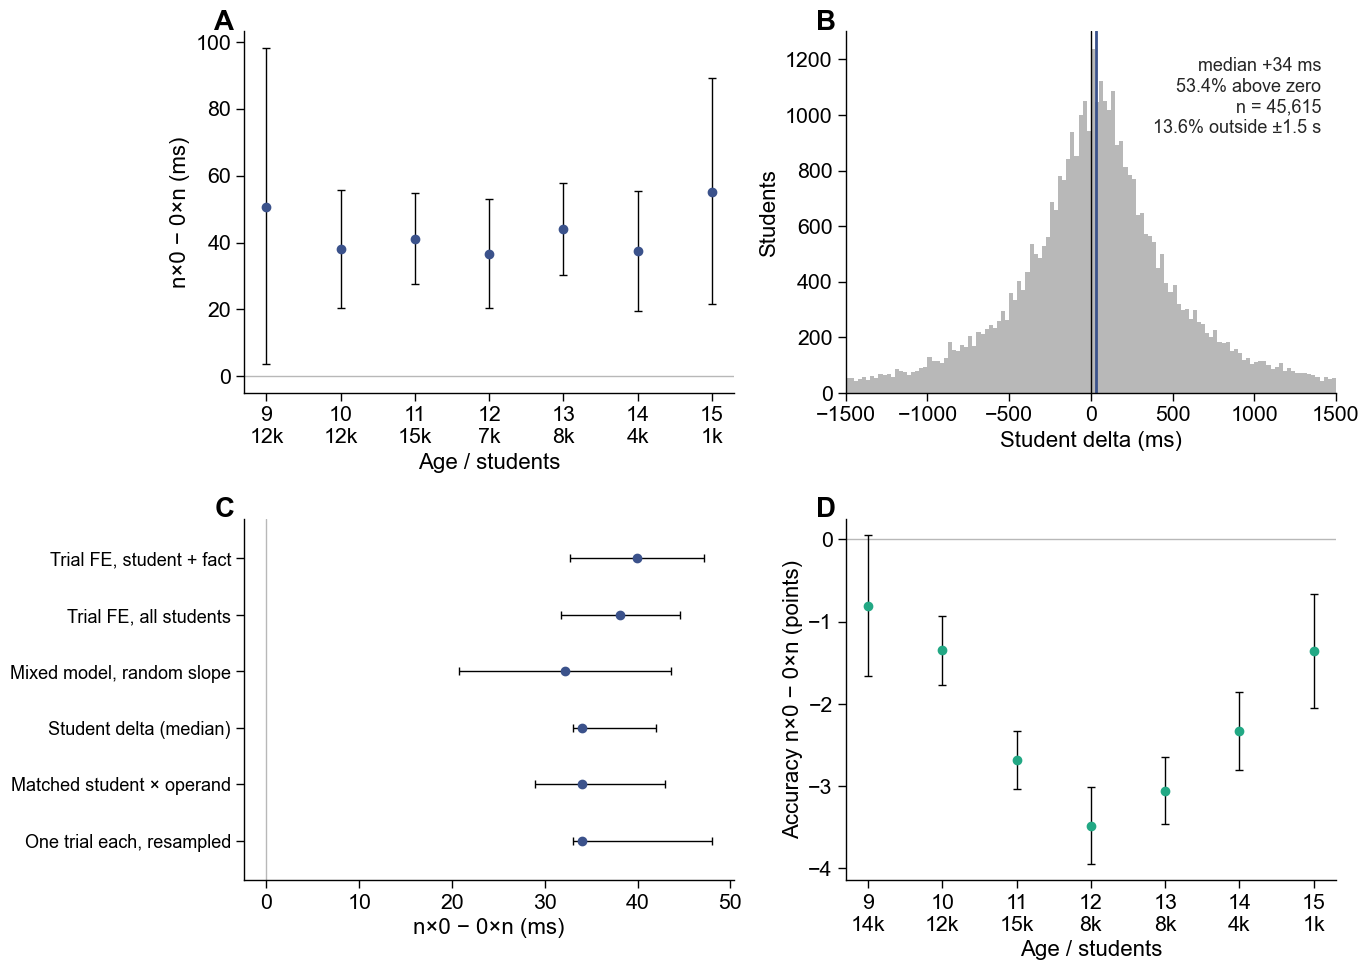

In [18]:
def robustness_figure(stem):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    (a, b), (cc, dd) = axes
    ages = rt_age.index.to_numpy()

    a.axhline(0, color="#B8B8B8", lw=1)
    a.errorbar(ages, rt_age.ms, yerr=np.vstack([rt_age.ms - rt_age.lo, rt_age.hi - rt_age.ms]),
               fmt="o", capsize=3, markersize=6, color=C_ZERO, ecolor="black", elinewidth=1)
    a.set_xticks(ages)
    a.set_xticklabels([f"{x:.0f}\n{n / 1000:.0f}k" for x, n in zip(ages, rt_age.students)])
    a.set_xlabel("Age / students", fontsize=FONT_MED); a.set_ylabel("n×0 − 0×n (ms)", fontsize=FONT_MED)

    lim = 1500                                  # dropped, not clipped: a pile-up at the edge is a lie
    x = w.delta[w.delta.abs() <= lim]
    b.hist(x, bins=120, color=C_OTHER, edgecolor="none")
    b.set_xlim(-lim, lim)
    b.axvline(0, color="black", lw=1)
    b.axvline(w.delta.median(), color=C_ZERO, lw=2)
    b.set_xlabel("Student delta (ms)", fontsize=FONT_MED)
    b.set_ylabel("Students", fontsize=FONT_MED)
    b.text(.97, .93, f"median {w.delta.median():+.0f} ms\n{100 * (w.delta > 0).mean():.1f}% above zero\n"
                     f"n = {len(w):,}\n{100 * (1 - len(x) / len(w)):.1f}% outside ±{lim / 1000:.1f} s",
           transform=b.transAxes, ha="right", va="top", fontsize=FONT_MED - 3)

    y = np.arange(len(summary))[::-1]
    cc.axvline(0, color="#B8B8B8", lw=1)
    cc.errorbar(summary.ms, y, xerr=np.vstack([summary.ms - summary.lo, summary.hi - summary.ms]),
                fmt="o", capsize=3, markersize=6, color=C_ZERO, ecolor="black", elinewidth=1)
    cc.set_yticks(y); cc.set_yticklabels(summary.index, fontsize=FONT_MED - 3)
    cc.set_xlabel("n×0 − 0×n (ms)", fontsize=FONT_MED); cc.set_ylim(-.7, len(summary) - .3)

    dd.axhline(0, color="#B8B8B8", lw=1)
    dd.errorbar(ages, acc_age.pp, yerr=np.vstack([acc_age.pp - acc_age.lo, acc_age.hi - acc_age.pp]),
                fmt="o", capsize=3, markersize=6, color=C_DIR[1], ecolor="black", elinewidth=1)
    dd.set_xticks(ages)
    dd.set_xticklabels([f"{x:.0f}\n{n / 1000:.0f}k" for x, n in zip(ages, acc_age.students)])
    dd.set_xlabel("Age / students", fontsize=FONT_MED)
    dd.set_ylabel("Accuracy n×0 − 0×n (points)", fontsize=FONT_MED)

    for ax, letter in zip([a, b, cc, dd], "ABCD"):
        ax.text(-.02, 1.06, letter, transform=ax.transAxes, fontweight="bold", fontsize=FONT_BIG,
                va="top", ha="right", color="black")
        sns.despine(ax=ax)
    fig.tight_layout(); paint_it_black(axes)
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    return fig

robustness_figure(f"rt_order_robustness_{YEAR}")

## Conclusion — what the data show

**The effect.** Answering `n×0` takes about **2% longer** than `0×n` — roughly **+35 to +40 ms** on a
median `0×n` response time of 2.03 s. Six estimators that make different assumptions agree:

| Estimator | Effect (ms) | 95% CI | Note |
|---|---|---|---|
| Trial FE, student + fact absorbed | **+39.9** | [32.7, 47.1] | t = 11.0, p < .001; +1.96% in log |
| Trial FE, all 112k students | +38.2 | [31.8, 44.6] | no control merge, so no selection |
| Mixed model, random intercept + slope | +32.2 | [20.8, 43.6] | 20,000-student subsample |
| Student delta, median | +34.0 | [33.0, 42.0] | 45,615 students, 53.4% above zero |
| Matched student × operand | +34.0 | [29.0, 43.0] | 27,375 students, same fact both orders |
| One trial per condition, 200 resamples | +34.0 | [33.0, 48.0] | equal weight per student |

**It is a within-student effect.** The trial-level estimate is identified inside students (student
absorbed as a fixed effect) and is unchanged when every student is forced to contribute exactly one trial
per condition. It is not produced by a subset of heavy users.

**It is stable across age**: +36.6 to +55.1 ms at ages 9–15, every confidence interval above zero, with
no trend (order × age p = .199).

**It does not depend on the student.** Neither multiplication proficiency (p = .252) nor general response
speed (p = .440) moderates it, and the same three regressions on the per-student delta are null. The log
specification already removes the mechanical possibility that slower students show larger millisecond
gaps: the effect is proportional, ≈ +1.9% at every level of ability and speed.

**Accuracy moves the same way — there is no speed–accuracy trade-off.** `n×0` is answered correctly
89.9% of the time against 92.2% for `0×n`: **−2.4 percentage points** within student and fact
(t = −26.4, p < .001), odds ratio 0.73 [0.72, 0.75]. Unlike the RT effect, this gap **grows with age**
(order × age −0.31 points per year, p < .001): −0.8 points at age 9, −3.5 at age 12, −1.4 at age 15.
So `n×0` is both slower and more error-prone, which is what a rule-first account predicts.

**What this analysis cannot establish.** The median student contributes 3 correct trials per condition
(max 15), so an individual student's effect is estimated with almost no information. The random-slope
variance comes out at essentially zero (SD 0.007 log units against a fixed effect of 0.016), but that
test has very little power here: read it as *no evidence of between-student heterogeneity*, not as
evidence that the effect is identical in every student. The defensible claim is a population-level
within-student shift, and that claim survives every robustness check above.

Two further limits carry over from the rest of the study: this is ES_2025 only (`DECISIONS #2`), and the
presentation order of items inside the test session is still not modelled (`DECISIONS #25`) — if one
order tends to be administered earlier in a session, a warm-up effect would imitate this result.

Mean-based statistics are much weaker than rank-based ones throughout (student deltas: t = 3.74,
p < .001 versus Wilcoxon p < 1e-40), the same heavy-tail problem recorded in `DECISIONS #19`.
The median is the number to quote.

## Sanity checks

In [19]:
assert c.nx0.isin([0, 1]).all() and set(c.n) <= set(range(1, 10))
assert not ((c.left_factor == 0) & (c.right_factor == 0)).any()          # 0×0 out (#15)
assert c.course_age.min() >= 9                                           # age 8 has no 0-facts (#12)
assert np.isclose(w.delta.median(), delta_stats["median"])
assert (rt_age.lo > 0).all(), "an age whose CI includes zero"
print(f"{len(c):,} correct trials | {c.student_uuid.nunique():,} students | "
      f"{len(w):,} with both orders | {len(matched):,} matched on the operand too")
print(f"trials per student per condition: median "
      f"{c.groupby(['student_uuid', 'nx0']).size().median():.0f}, "
      f"max {c.groupby(['student_uuid', 'nx0']).size().max()}")

316,277 correct trials | 59,175 students | 45,615 with both orders | 27,375 matched on the operand too
trials per student per condition: median 3, max 15
